<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº5
#### Federico Borello

### Consigna

A partir de la siguiente plantilla:

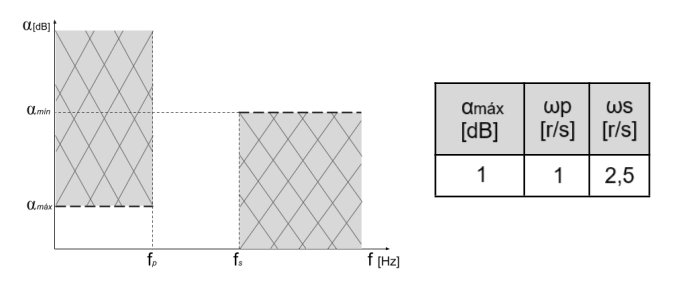


1. Obtener la función transferencia $T(s)$ de Bessel para N: 2, 3 y 4 normalizados para $D(\omega=0)=1[s]$ utilizando el método de Storch: ver Schaumann, R. - Van Valkenburg, Mac E., Design of Analog Filters, Capítulo 10: Delay Filters. Sección 10.2: Bessel-Thomson Response. Página 403.
2. Elegir la $T(s)$ con el mínimo orden que cumpla con $\alpha_{\text{máx}}=1[dB]$
3. Evaluar el retardo de grupo $D(\omega=2.5)$ y expresar en forma porcentual [%] el error o desviamiento respecto a $D(\omega=0)$
4. Sintetizar el circuito NORMALIZADO con estructuras Sallen-Key con K=1 (real, negativa y unitaria).


**Bonus:**

+10 💎 Simular numéricamente en Python.

+10 💎 DESNORMALIZAR los componentes para obtener un $D(\omega=0)=200[\mu s]$

+10 💎 Simular circuitalmente en LTSpice con los valores DESNORMALIZADOS y medir el $D(\omega)$.

+10 🍺 Presentación en Jupyter Notebook.

In [1]:
from IPython.display import HTML

file = "./TS5_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt
import utils.tools as ut

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import scipy.signal as sig

# Analisis Previo

Para obtener una transferencia Bessel-Thomson, o de máxima planicidad de retardo de grupo, se procede con el método de Storch. Previo a eso, se debe tener en cuenta las siguientes expresiones matemáticas:

$$
T(s) = \cfrac{1}{e^s} = \cfrac{1}{\sinh{(s)} + \cosh{(s)}}
$$

Se emplea una expresión práctica para llegar a la función deseada:

$$
\coth(s) = \frac{\cosh(s)}{\sinh(s)} = \cfrac{1}{s} + \cfrac{1}{\cfrac{3}{s} + \cfrac{1}{\cfrac{5}{s} + \cfrac{1}{\cfrac{7}{s} + \cdots}}}
$$

El método de Storch para obtener la transferencia deseada, consiste en utilizar la expresión de $\coth{(s)}$ hasta el orden deseado, se simplifica y se llega a una fracción cuyo nominado es el $\cosh{(s)}$ y el denominador es el $\sinh{(s)}$. A la suma $\cosh{(s)}|_n + \sinh{(s)}|_n$ se la considera un polinomio de Bessel $\mathcal{B}_n(s)$.

Por último, la transferencia queda representada como:

$$
T(s) = \cfrac{\mathcal{B}_n(0)}{\mathcal{B}_n(s)}
$$

## Caso de Estudio

Se realizó un análisis previo a mano (adjunto en el PDF). Y se concluye que el orden deseado en 3. Se verifica de manera rápida con python.

In [3]:
def coth_storch_sympy(s, terms=10):
    """
    Aproxima simbólicamente coth(s) usando su expansión en fracción continua.

    Parámetros:
        s (sympy.Symbol o número): variable o valor simbólico
        terms (int): número de términos de la fracción continua

    Retorna:
        expresión simbólica de coth(s)
    """
    frac = 0
    for n in reversed(range(1, terms)):
        a = 2 * n + 1
        frac = 1 / (a / s + frac)

    return 1 / s + frac


s = sp.Symbol("s")
coth_approx = coth_storch_sympy(s, terms=3)

simplified = sp.simplify(coth_approx)
display(
    Markdown(
        f"### Aproximación simbólica de coth(s) usando su expansión en fracción continua:"
    )
)
display(Markdown(f"$$ coth(s) = {sp.latex(simplified)} $$"))

### Aproximación simbólica de coth(s) usando su expansión en fracción continua:

$$ coth(s) = \frac{3 \left(2 s^{2} + 5\right)}{s \left(s^{2} + 15\right)} $$

In [4]:
num = simplified.as_numer_denom()[0]
den = simplified.as_numer_denom()[1]
display(Markdown(f"### Numerador y denominador de la aproximación:"))
display(Markdown(f"$$\\cosh(s) \\rightarrow \\text{{Numerador}}: {sp.latex(num)} $$"))
display(Markdown(f"$$\\sinh(s) \\rightarrow \\text{{Denominador}}: {sp.latex(den)} $$"))

bessel_n3 = num + den

bessel_n3 = sp.expand(bessel_n3)
display(Markdown(f"### Aproximación de Bessel:"))
display(Markdown(f"$$B_3(s) = {sp.latex(bessel_n3)}$$"))

T = bessel_n3.subs({s: 0}) / bessel_n3

display(Markdown(f"### Transferecia de Máxima Planicidad de Retardo:"))
display(Markdown(f"$$T(s) = \\frac{{B_3(0)}}{{B_3(s)}} = {sp.latex(T)}$$"))

### Numerador y denominador de la aproximación:

$$\cosh(s) \rightarrow \text{Numerador}: 6 s^{2} + 15 $$

$$\sinh(s) \rightarrow \text{Denominador}: s \left(s^{2} + 15\right) $$

### Aproximación de Bessel:

$$B_3(s) = s^{3} + 6 s^{2} + 15 s + 15$$

### Transferecia de Máxima Planicidad de Retardo:

$$T(s) = \frac{B_3(0)}{B_3(s)} = \frac{15}{s^{3} + 6 s^{2} + 15 s + 15}$$

Se pide un $\alpha_{max} = 1[dB]$. Para verificar eso utilizamos la siguiente expresión:

$$
|T(j\omega)| = 10^{-\alpha(\omega)/20}
$$

Y se evalua $\omega = \omega_p$, que en este caso $\omega_p = 1$

In [5]:
# Obtengo el módulo de la función de transferencia

T_jw = T.subs({s: 1j * sp.Symbol("w")})
display(Markdown(f"$$T(jw) = {sp.latex(T_jw)}$$"))

w = sp.Symbol("w", real=True)
T_jw = sp.expand_complex(T.subs({s: 1j * w}))
T_jw_mod = sp.Abs(T_jw)
T_jw_mod = sp.simplify(T_jw_mod)
display(Markdown(f"$$|T(jw)| = {sp.latex(T_jw_mod.evalf(3))}$$"))

T_jw_mod_at_1 = T_jw_mod.subs({w: 1})

display(Markdown(f"$$|T(1)| = {T_jw_mod_at_1:.3f}$$"))

alpha = -20 * sp.log(T_jw_mod_at_1) / sp.log(10)

display(Markdown(f"$$\\alpha = -20 \\log_{{10}}(|T(1)|) = {alpha:.3f}$$"))

$$T(jw) = \frac{15}{- 1.0 i w^{3} - 6.0 w^{2} + 15.0 i w + 15}$$

$$|T(jw)| = \frac{1.0}{\left(0.00444 w^{6} + 0.0267 w^{4} + 0.2 w^{2} + 1.0\right)^{0.5}}$$

$$|T(1)| = 0.901$$

$$\alpha = -20 \log_{10}(|T(1)|) = 0.903$$

Se verifica que el $\alpha < \alpha_{max} = 1[dB]$.

Sólo falta evaluar el retardo de grupo en los puntos requeridos.

$$
D = - \cfrac{d\angle T(j\omega)}{d\omega}
$$

In [6]:
T_jw_phase = sp.arg(T_jw)
T_jw_phase = sp.simplify(T_jw_phase)

D = -sp.diff(T_jw_phase, w)
D = D.simplify()
display(Markdown(f"$$D = - \\frac{{d\\angle T(jw)}}{{dw}} = {sp.latex(D.evalf(3))}$$"))

D_at_0 = D.subs({w: 0})
display(Markdown(f"$$D(0) = {D_at_0:.3f}$$"))

D_at_2p5 = D.subs({w: 2.5})
display(Markdown(f"$$D(2.5) = {D_at_2p5:.3f}$$"))

error = (D_at_2p5 - D_at_0) / D_at_0 * 100

display(
    Markdown(
        f"$$\\text{{Error}} = \\frac{{D(2.5) - D(0)}}{{D(0)}} = {round(error, 1)}\\%$$"
    )
)

$$D = - \frac{d\angle T(jw)}{dw} = \frac{0.000119 w^{10} + 0.0016 w^{8} + 0.0151 w^{6} + 0.0933 w^{4} + 0.4 w^{2} + 1.0}{1.98 \cdot 10^{-5} w^{12} + 0.000237 w^{10} + 0.00249 w^{8} + 0.0196 w^{6} + 0.0933 w^{4} + 0.4 w^{2} + 1.0}$$

$$D(0) = 1.000$$

$$D(2.5) = 0.752$$

$$\text{Error} = \frac{D(2.5) - D(0)}{D(0)} = -24.8\%$$

## Análisis de la Transferencia

$$H(s) = 15 \frac{1}{1s^3 + 6s^2 + 15s + 15}$$

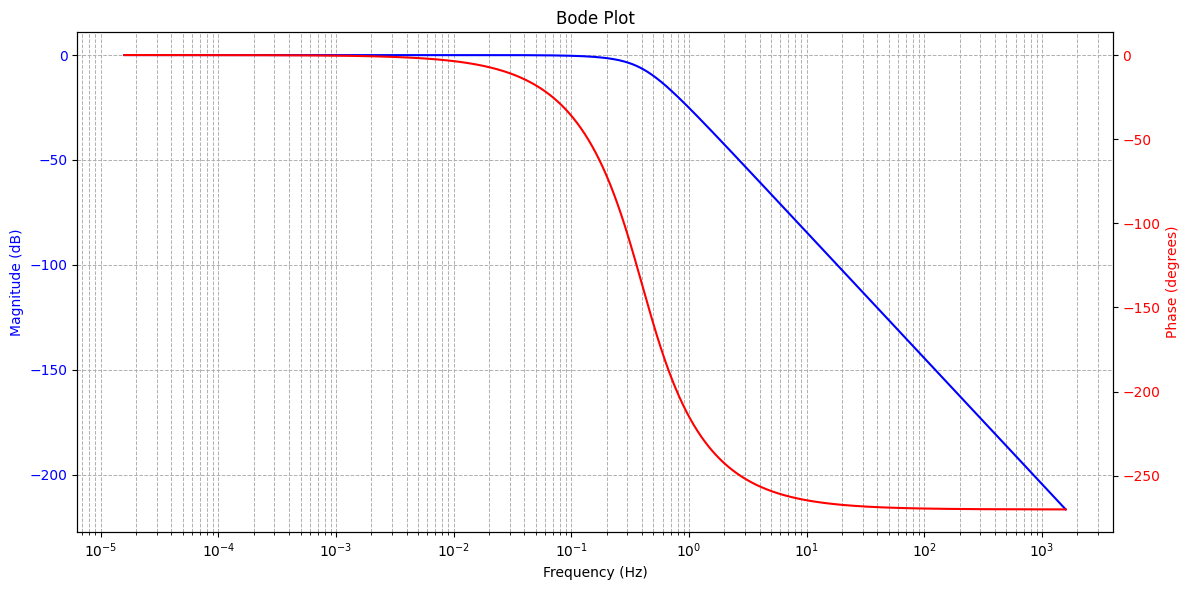


Ganancia en $\omega_0$ -0.902[dB]


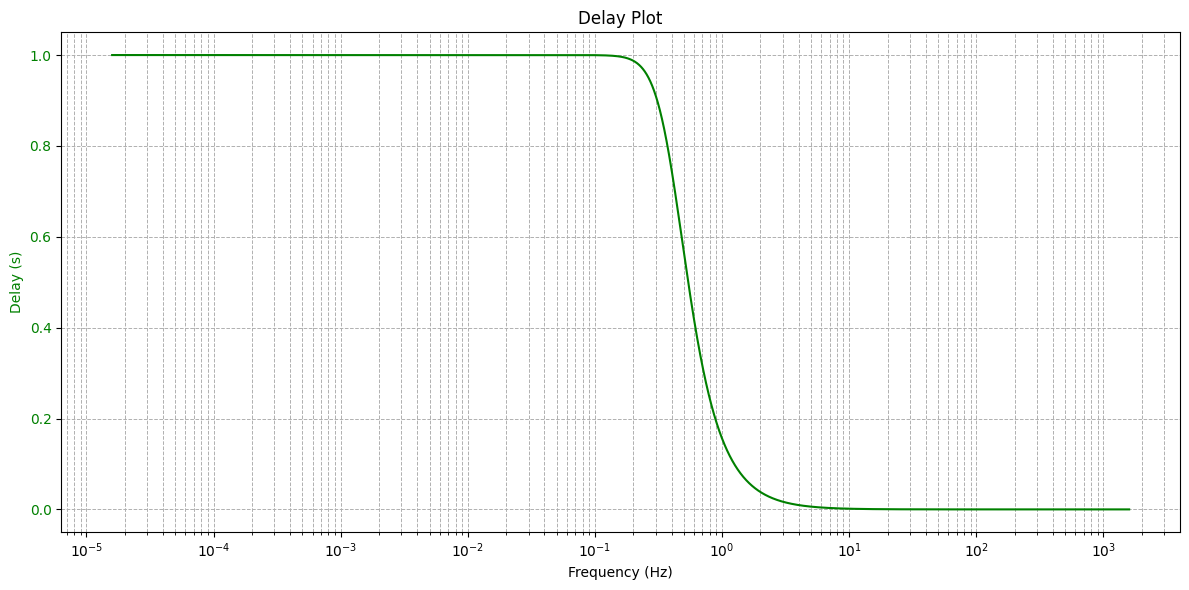


Retardo de grupo en $\omega = 0.0 \; \rightarrow \; 1.000[s]$

Retardo de grupo en $\omega = 1.0  \; \rightarrow \;  0.996[s]$

Retardo de grupo en $\omega = 2.5 \; \rightarrow \; 0.752[s]$


In [7]:
s = sp.symbols("s")

# Defino la transferencia T(s)
num = 15
den = s**3 + 6 * s**2 + 15 * s + 15
T = num / den

_w0 = 1

(magnitude_db, frequencies, _) = uplt.plot_tf(T, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - _w0 / (2 * np.pi)))
magnitude_at_w0 = magnitude_db[idx]

markdown_text = f"""
Ganancia en $\omega_0$ {magnitude_at_w0:.3f}[dB]
"""

display(Markdown(markdown_text))

(delay, frequencies) = uplt.plot_delay(T, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - _w0 / (2 * np.pi)))
delay_at_w0 = delay[idx]

delay_at_2_5 = delay[np.argmin(np.abs(frequencies - 2.5 / (2 * np.pi)))]

markdown_text = f"""
Retardo de grupo en $\omega = 0.0 \; \\rightarrow \; {delay[0]:.3f}[s]$

Retardo de grupo en $\omega = 1.0  \; \\rightarrow \;  {delay_at_w0:.3f}[s]$

Retardo de grupo en $\omega = 2.5 \; \\rightarrow \; {delay_at_2_5:.3f}[s]$
"""

display(Markdown(markdown_text))

## Síntesis

Se pide sintetizar la transferencia con redes Sallen-Key con $K=1$, como la transferencia es de orden 3, se procede a utilizar un Sallen-Key y un filtro RC, separados por un `buffer`.

$$
T(s)\Big|_{n=3} = \cfrac{15}{s^3 + 6s^2 + 15s + 15} 
$$

### Sallen-Key - $k=1$

$$
H(s) = \cfrac{\frac{G_1\, G_2}{C_1 \, C_2}}{s^2 + s \, \frac{G_1 + G_2}{C_2} + \frac{G_1\, G_2}{C_1 \, C_2}}
$$

Por lo tanto se tiene la siguiente expresión simplificada:

$$
H(s) = k \;  \cfrac{{\omega_0}^2}{s^2 + s \, \frac{\omega_0}{Q} + {\omega_0}^2}
$$

Siendo los parámetros característicos del filtro:

$$k = 1$$

$$\omega_0 =  \frac{\sqrt{G_1 \, G_2}}{\sqrt{C_1 \, C_2}}$$

$$Q =  \omega_0 \, \frac{C_2}{G_1 + G_2}$$

### Filtro RC

$$
H(s) = \cfrac{\frac{1}{R \, C}}{s + \frac{1}{R \, C}}
$$

Por lo tanto se tiene la siguiente expresión simplificada:

$$
H(s) = \cfrac{\omega_0}{s + \omega_0}
$$


In [8]:
b = [15]
a = [1, 6, 15, 15]

sections = ut.bessel_thomson_sos_sects(b, a)

$$H_{1}(s) = \frac{2.32}{1.0 s + 2.32}$$

$$H_{2}(s) = \frac{6.46}{1.0 s^{2} + 3.68 s + 6.46}$$

In [9]:
TF = sections[0] * sections[1]
TF = sp.simplify(sp.expand(TF))
TF.evalf(2)

15.0/(1.0*s**3 + 6.0*s**2 + 15.0*s + 15.0)

Se empieza a sintetizar el Sallen-Key con $G_2 == G_1$ y como ejemplo, se desnormaliza con una $\omega_n = 5 [krad/s]$ y $R_2 = 56k$.

In [10]:
G1, G2, C1, C2, w0, Q = sp.symbols("G1 G2 C1 C2 \omega_0 Q", real=True, positive=True)

_w0 = np.sqrt(6.46)
_Q = _w0 / 3.68

R2_val = 56e3
G2_val = 1 / R2_val
wn = 5e3

# Ecuaciones
w0_expr = sp.Eq(w0, sp.sqrt(G1 * G2 / (C1 * C2)))
Q_expr = sp.Eq(Q, w0 * C2 / (G1 + G2))

C2_expr = sp.solve(Q_expr, C2)[0]
C1_expr = sp.solve(w0_expr.subs(C2, C2_expr), C1)[0]
C2_expr = C2_expr.subs({G1: G2})
C1_expr = C1_expr.subs({G1: G2})
markdown_text = f"""
$$C_2 = {sp.latex(C2_expr)}$$
$$C_1 = {sp.latex(C1_expr)}$$
"""
display(Markdown(markdown_text))

C2_val_n = C2_expr.subs({G2: 1, w0: 1, Q: _Q})
C1_val_n = C1_expr.subs({G2: 1, w0: 1, Q: _Q})
markdown_text = f"""
### Valores numéricos normalizados:"
$$C_2 = {C2_val_n.evalf(3)}$$
$$C_1 = {C1_val_n.evalf(3)}$$
"""
display(Markdown(markdown_text))

C2_val = C2_expr.subs({G2: G2_val, w0: _w0 * wn, Q: _Q})
C1_val = C1_expr.subs({G2: G2_val, w0: _w0 * wn, Q: _Q})
markdown_text = f"""
### Valores numéricos:
$$C_2 = {C2_val.evalf(3)}$$
$$C_1 = {C1_val.evalf(3)}$$
"""
display(Markdown(markdown_text))

C1_check = C1_val_n / (_w0 * wn) * G2_val
C2_check = C2_val_n / (_w0 * wn) * G2_val
markdown_text = f"""
### Verificación de resultados ($C = \\frac{{C_{{\\text{{normalizado}}}} \Omega_Y}}{{\\omega_0 \; \\omega_n}}$):
$$C_2 = {C2_check.evalf(3)}$$
$$C_1 = {C1_check.evalf(3)}$$
"""
display(Markdown(markdown_text))


$$C_2 = \frac{2 G_{2} Q}{\omega_{0}}$$
$$C_1 = \frac{G_{2}}{2 Q \omega_{0}}$$



### Valores numéricos normalizados:"
$$C_2 = 1.38$$
$$C_1 = 0.724$$



### Valores numéricos:
$$C_2 = 1.94E-9$$
$$C_1 = 1.02E-9$$



### Verificación de resultados ($C = \frac{C_{\text{normalizado}} \Omega_Y}{\omega_0 \; \omega_n}$):
$$C_2 = 1.94E-9$$
$$C_1 = 1.02E-9$$


Se procede a sintetizar la sección del filtro RC.

In [11]:
R, C, w0 = sp.symbols("R C \omega_0", real=True, positive=True)

_w0 = 2.32

w0_expr = sp.Eq(w0, 1 / (R * C))
R_expr = sp.solve(w0_expr, R)[0]
C_expr = sp.solve(w0_expr, C)[0]

markdown_text = f"""
### Ecuación para el resistor:
Es mas sencillo setear un capacitador y calcular el resistor:
$$R = {sp.latex(R_expr)}$$
"""
display(Markdown(markdown_text))

C_val_n = C_expr.subs({R: 1, w0: 1})
R_val = R_expr.subs({C: 10e-9, w0: _w0 * wn})
markdown_text = f"""
### Valor numérico normalizado:
$$C = {C_val_n.evalf(3)}$$
### Valor numérico de R seteando $C = 10[nF]$ y $\omega_n = 5[krad/s]$:
$$R = {R_val.evalf(3)}$$
"""
display(Markdown(markdown_text))

C_check = C_val_n / (_w0 * wn * R_val)
markdown_text = f"""
### Verificación de resultados ($C = \\frac{{C_{{\\text{{normalizado}}}}}}{{\\omega_0 \; \\omega_n \; \Omega_Z}}$):
$$C = {C_check.evalf(3)}$$
"""
display(Markdown(markdown_text))


### Ecuación para el resistor:
Es mas sencillo setear un capacitador y calcular el resistor:
$$R = \frac{1}{C \omega_{0}}$$



### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de R seteando $C = 10[nF]$ y $\omega_n = 5[krad/s]$:
$$R = 8.62E+3$$



### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 1.00E-8$$


Por lo tanto, para sintetizar la transferencia normalizada:

- Sallen-Key
  - $C_1 = 0.724$
  - $C_2 = 1.38$
  - $R_1 == R_2 = 1/\Omega_Y$
  - $\Omega_Y = G_2 = 1$
  - $\Omega_{\omega_0} = \sqrt{6.46}$
- RC
  - $C = 1$
  - $R = \Omega_Z$
  - $\Omega_Y = G_2 = 1$
  - $\Omega_{\omega_0} = 2.32$

## Desnormalización

En el apartado anterior se dio un ejemplo con $5 [krad/s]$. Lo cual es $\omega_C = \frac{1}{D}$. Si queremos que $D = 200[\mu s]$, $\omega_c = 5 [krad/s]$.

- Sallen-Key
  - $C_1 = 1[nF]$
  - $C_2 = 2[nF]$
  - $R_1 == R_2 = 56[k\Omega]$
- RC
  - $C = 10[nF]$
  - $R = 8.620[k\Omega]$

In [12]:
# Valores Sallen-Key
R2_val = 56e3
G2_val = 1 / R2_val
C1_val = 1e-9
C2_val = 2e-9

# Defino la primer transferencia T1(s)
num = w0**2
den = s**2 + s * w0 / Q + w0**2
T1 = num / den

w0_expr = sp.sqrt(G1 * G2 / (C1 * C2))
Q_expr = w0 * C2 / (G1 + G2)

values = {Q: Q_expr, w0: w0_expr}

T1 = T1.subs(values)
T1 = T1.subs({G1: G2, G2: G2_val, C1: C1_val, C2: C2_val})
T1

159438775.510204/(s**2 + 17857.1428571429*s + 159438775.510204)

In [13]:
# Valores RC
R_val = 8.620e3
C = 10e-9

# Defino la segunda transferencia T2(s)
num = w0
den = s + w0
T2 = num / den

w0_expr = 1 / (R * C)
T2 = T2.subs({w0: w0_expr})
T2 = T2.subs({R: R_val, C: C})
T2

11600.9280742459/(s + 11600.9280742459)

In [14]:
T3 = T1 * T2
T3

1849637766939.72/((s + 11600.9280742459)*(s**2 + 17857.1428571429*s + 159438775.510204))

$$H(s) = 1.85E^{12} \frac{1}{1s^3 + 2.95E^{4}s^2 + 3.67E^{8}s + 1.85E^{12}}$$

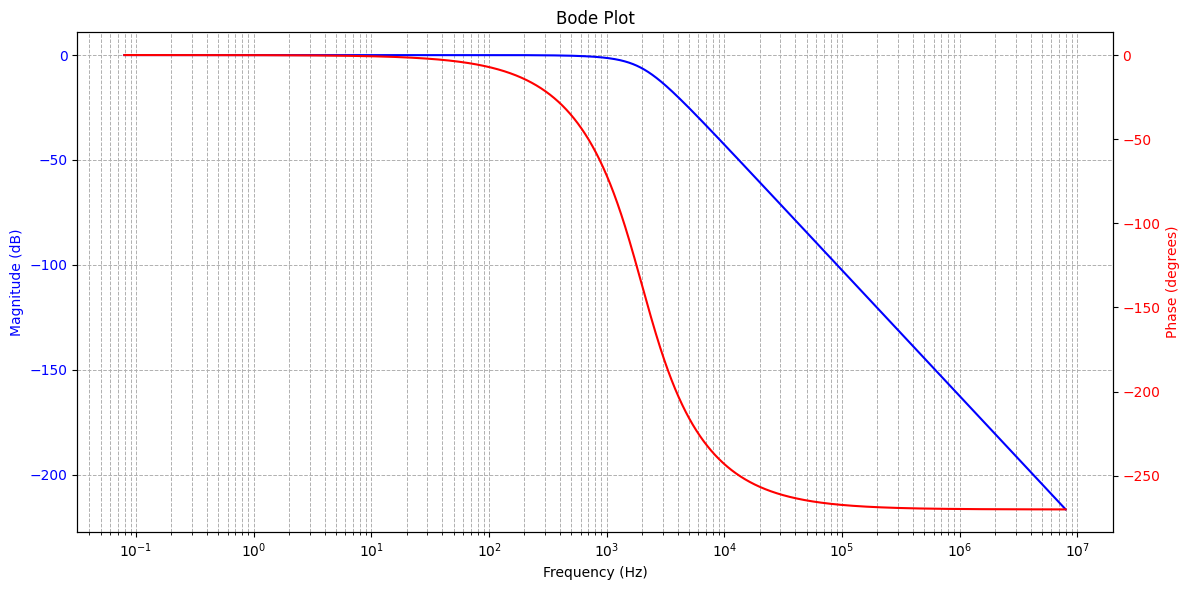


Ganancia en $\omega_0$ -0.844[dB]


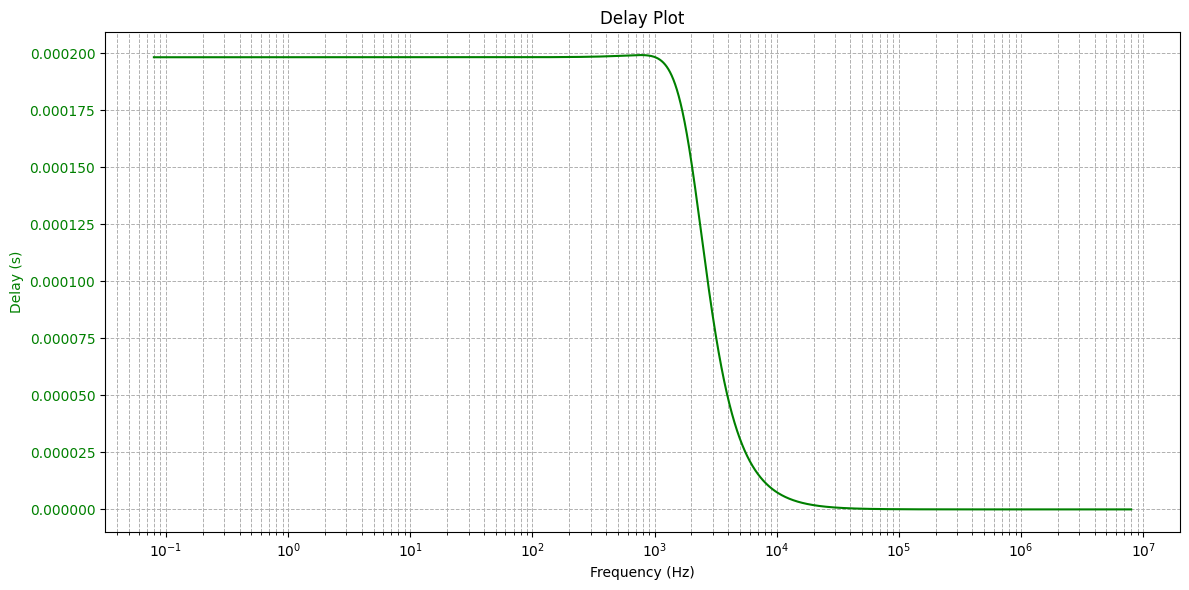


Retardo de grupo en $\omega = 0.0 \; \rightarrow \; 198 μs$

Retardo de grupo en $\omega = 1.0 * 5000.0  \; \rightarrow \;  199 μs$

Retardo de grupo en $\omega = 2.5 * 5000.0\; \rightarrow \; 153 μs$


In [15]:
_w0 = 5e3
(magnitude_db, frequencies, _) = uplt.plot_tf(T3, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - _w0 / (2 * np.pi)))
magnitude_at_w0 = magnitude_db[idx]

markdown_text = f"""
Ganancia en $\omega_0$ {magnitude_at_w0:.3f}[dB]
"""

display(Markdown(markdown_text))

(delay, frequencies) = uplt.plot_delay(T3, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - _w0 / (2 * np.pi)))
delay_at_w0 = delay[idx]

delay_at_2_5 = delay[np.argmin(np.abs(frequencies - 2.5 * _w0 / (2 * np.pi)))]

markdown_text = f"""
Retardo de grupo en $\omega = 0.0 \; \\rightarrow \; {uplt.eng_format(delay[0], "s")}$

Retardo de grupo en $\omega = 1.0 * {_w0}  \; \\rightarrow \;  {uplt.eng_format(delay_at_w0, "s")}$

Retardo de grupo en $\omega = 2.5 * {_w0}\; \\rightarrow \; {uplt.eng_format(delay_at_2_5, "s")}$
"""

display(Markdown(markdown_text))

## Gráfico de Modulo y Fase

### Simulación con LT Spice

Circuito:

<div align=center>

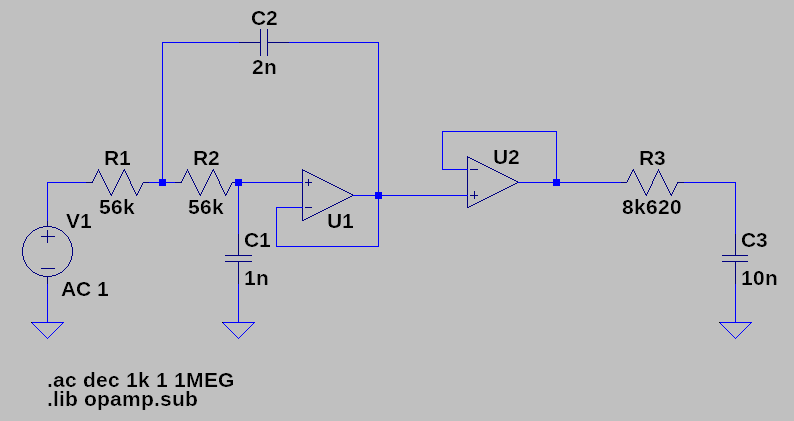

</div>

Módulo y Fase:

<div align=center>

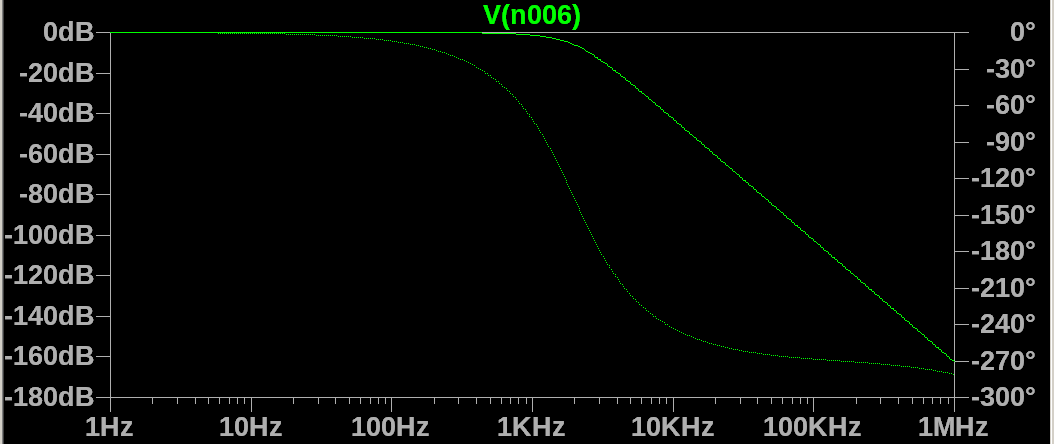

</div>

Retardo de Grupo:

<div align=center>

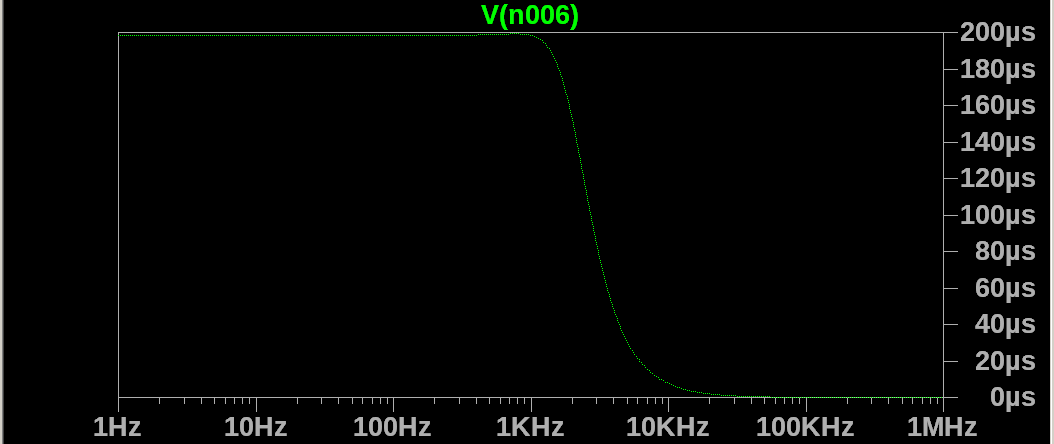

</div>

<a href="./TS5.asc" download="TS5.asc">Descargar TS5.asc</a>